# 200 chimpancés. Una comunidad fracturada. Una guerra civil.

El grupo salvaje más grande de chimpancés jamás estudiado se rompió en dos — y lo que siguió fueron 24 ataques letales, al menos 7 machos adultos asesinados y 17 crías muertas.

---

**Paper:** Sandel, A.A. *et al.* (2026). *Lethal conflict after group fission in wild chimpanzees.* Science, 388(6794).
**DOI:** [10.1126/science.adz4944](https://doi.org/10.1126/science.adz4944)
**Datos:** [Zenodo](https://doi.org/10.5281/zenodo.18626723) (redes sociales) · [Zenodo](https://doi.org/10.5281/zenodo.18603419) (uso espacial)

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-04-10-conflicto-letal-chimpances-fision/notebook.ipynb)
[Pendiente]

## ¿Qué midieron?

En el Parque Nacional de Kibale, Uganda, un equipo de investigación lleva **30 años** observando a los chimpancés de Ngogo — la comunidad salvaje más grande registrada, con casi 200 individuos. Usando datos de comportamiento y análisis de redes sociales desde 1998, documentaron cómo esta comunidad pasó de ser un grupo cohesivo a polarizarse en 2015, fracturarse permanentemente en 2018, y escalar a violencia letal sostenida.

Es el primer caso documentado de algo que se parece a una **guerra civil** en un pariente cercano nuestro — sin los marcadores culturales (religión, etnia, idioma) que los humanos suelen necesitar para dividirse.

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
ANIO_QUIEBRE = 2015        # Año en que la polarización se dispara
ANIO_FISION = 2018         # Año en que los dos grupos se separan definitivamente
ATAQUES_TOTALES = 24       # Ataques letales documentados (2018-2024)
MACHOS_MUERTOS = 7         # Machos adultos (≥12 años) asesinados (mínimo)
CRIAS_MUERTAS = 17         # Crías muertas (14 observadas + 3 inferidas)

COLOR_WEST = '#D97706'     # Amber — grupo Western
COLOR_CENTRAL = '#2563EB'  # Azul CaM — grupo Central-East
COLOR_ALERTA = '#DC2626'   # Rojo — eventos letales
COLOR_PRE = '#BBBBBB'      # Gris — periodo pre-fisión
COLOR_QUIEBRE = '#7C3AED'  # Violeta — año de quiebre

FUENTE = 'Fuente: Sandel et al. (2026), Science | Datos: Zenodo (redes + uso espacial)'

# ══════════════════════════════════════════════════════════════

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os, urllib.request

# Estilo CaM
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(
            'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main/cam.mplstyle', style_file)
plt.style.use(style_file)

# Datos
red = pd.read_csv('datos/red_social.csv')
grupos = pd.read_csv('datos/grupo_composicion.csv')
miembros = pd.read_csv('datos/cluster_membership_by_year.csv')

print(f"Red social: {len(red)} años ({red['year'].min()}–{red['year'].max()})")
print(f"Composición: {len(grupos)} años, {grupos['total'].max()} individuos en pico")
print(f"Membership: {len(miembros)} registros, {miembros['year'].nunique()} años")
print(f"\nConexiones promedio por individuo:")
print(f"  Pre-fisión (1998-2014): {red[red['year']<=2014]['avg_degree'].mean():.1f}")
post_deg = red[red['year']>=2019]['avg_degree']
print(f"  Post-fisión (2019-2022): {post_deg.mean():.1f} (n={len(post_deg)}, Mann-Whitney p=0.002, Cohen\'s d=4.99)")

Red social: 24 años (1998–2022)
Composición: 25 años, 124 individuos en pico
Membership: 77 registros, 25 años

Conexiones promedio por individuo:
  Pre-fisión (1998-2014): 29.9
  Post-fisión (2019-2022): 13.3 (n=3, Mann-Whitney p=0.002, Cohen's d=4.99)


## La red social se desmorona

Aquí está.

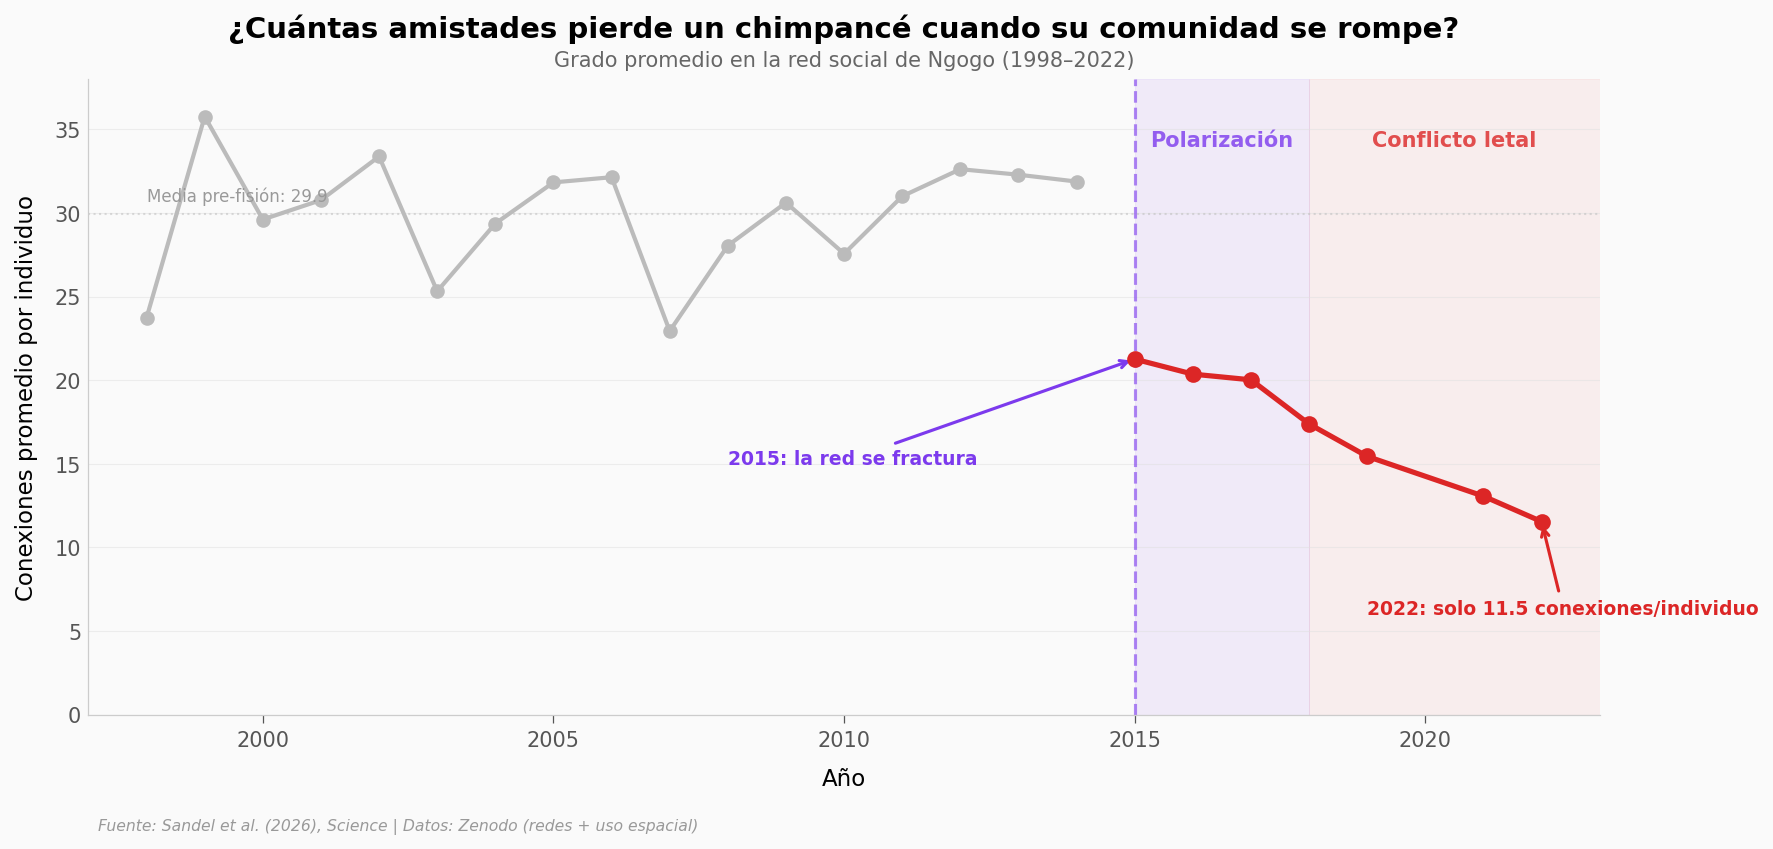

In [2]:
fig, ax = plt.subplots(figsize=(13, 5.5))

# Separar pre y post quiebre
pre = red[red['year'] < ANIO_QUIEBRE]
post = red[red['year'] >= ANIO_QUIEBRE]

# Línea pre-fisión
ax.plot(pre['year'], pre['avg_degree'], '-o', color=COLOR_PRE,
        markersize=6, linewidth=2, zorder=3, label='Pre-fisión')

# Línea post-quiebre
ax.plot(post['year'], post['avg_degree'], '-o', color=COLOR_ALERTA,
        markersize=7, linewidth=2.5, zorder=4, label='Post-quiebre')

# Zona de polarización
ax.axvspan(ANIO_QUIEBRE, ANIO_FISION, alpha=0.08, color=COLOR_QUIEBRE, zorder=1)
ax.text(2016.5, 34, 'Polarización', fontsize=10, color=COLOR_QUIEBRE,
        ha='center', fontweight='bold', alpha=0.8)

# Zona de conflicto letal
ax.axvspan(ANIO_FISION, 2023, alpha=0.06, color=COLOR_ALERTA, zorder=1)
ax.text(2020.5, 34, 'Conflicto letal', fontsize=10, color=COLOR_ALERTA,
        ha='center', fontweight='bold', alpha=0.8)

# Año de quiebre
ax.axvline(x=ANIO_QUIEBRE, color=COLOR_QUIEBRE, linewidth=1.5,
           linestyle='--', alpha=0.6, zorder=2)

# Anotaciones
ax.annotate('2015: la red se fractura',
            xy=(2015, 21.26), xytext=(2008, 15),
            fontsize=9, color=COLOR_QUIEBRE, fontweight='bold',
            arrowprops=dict(arrowstyle='->', color=COLOR_QUIEBRE, lw=1.5))

ax.annotate(f'2022: solo {red[red["year"]==2022]["avg_degree"].values[0]:.1f} conexiones/individuo',
            xy=(2022, 11.54), xytext=(2019, 6),
            fontsize=9, color=COLOR_ALERTA, fontweight='bold',
            arrowprops=dict(arrowstyle='->', color=COLOR_ALERTA, lw=1.5))

# Media pre-fisión como referencia
media_pre = red[red['year'] <= 2014]['avg_degree'].mean()
ax.axhline(y=media_pre, color=COLOR_PRE, linewidth=1, linestyle=':', alpha=0.5)
ax.text(1998, media_pre + 0.8, f'Media pre-fisión: {media_pre:.1f}',
        fontsize=8, color='#999999')

ax.set_xlabel('Año', fontsize=11)
ax.set_ylabel('Conexiones promedio por individuo', fontsize=11)
ax.set_title('¿Cuántas amistades pierde un chimpancé cuando su comunidad se rompe?',
             fontsize=14, fontweight='bold', pad=20)
ax.text(0.5, 1.02, 'Grado promedio en la red social de Ngogo (1998–2022)',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

ax.set_xlim(1997, 2023)
ax.set_ylim(0, 38)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/hero_red_social.png', dpi=200, bbox_inches='tight')
plt.show()

### Lectura guiada

Antes de 2015, cada chimpancé compartía tiempo con unas **30 compañeros** en promedio. Eran el grupo salvaje más grande conocido — casi 200 individuos que cazaban juntos, patrullaban territorio juntos, se acicalaban mutuamente.

En 2015, algo se quiebra. Las conexiones caen un 33% en un solo año. Y después de eso, nunca se recuperan. Para 2022, cada individuo mantiene solo **11,5 conexiones** — una caída del 67,7% desde el pico histórico (35,8 conexiones en 1999).

Lo que estamos viendo es una comunidad que se desgarra. No fue un evento súbito: fue una erosión sostenida de los lazos sociales, año tras año, durante siete años.

## ¿Cómo se repartió la comunidad?

Veamos a quiénes se llevó cada bando.

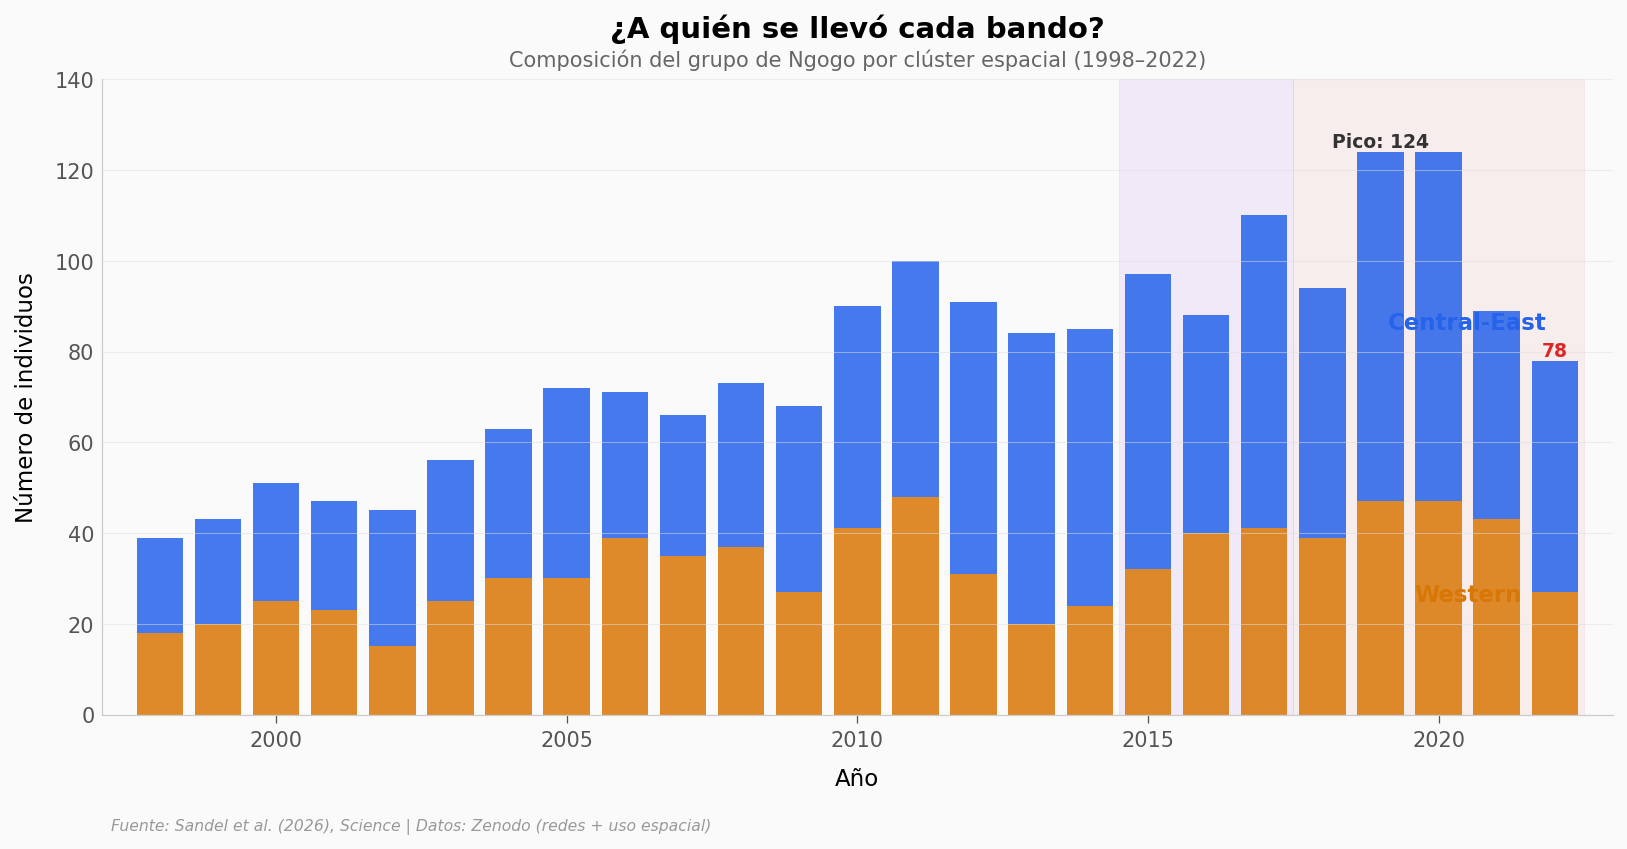

In [3]:
fig, ax = plt.subplots(figsize=(13, 5.5))

years = grupos['year']
west = grupos['west']
central = grupos['central_east']

# Barras apiladas
ax.bar(years, west, color=COLOR_WEST, alpha=0.85, label='Western', width=0.8)
ax.bar(years, central, bottom=west, color=COLOR_CENTRAL, alpha=0.85, label='Central-East', width=0.8)

# Zona de polarización
ax.axvspan(ANIO_QUIEBRE - 0.5, ANIO_FISION - 0.5, alpha=0.08, color=COLOR_QUIEBRE, zorder=0)

# Zona de conflicto
ax.axvspan(ANIO_FISION - 0.5, 2022.5, alpha=0.06, color=COLOR_ALERTA, zorder=0)

# Inline labels
ax.text(2020.5, 25, 'Western', fontsize=11, color=COLOR_WEST,
        fontweight='bold', ha='center')
ax.text(2020.5, 85, 'Central-East', fontsize=11, color=COLOR_CENTRAL,
        fontweight='bold', ha='center')

# Pico y caída
pico_year = grupos.loc[grupos['total'].idxmax(), 'year']
pico_total = grupos['total'].max()
final_total = grupos[grupos['year'] == 2022]['total'].values[0]

ax.annotate(f'Pico: {pico_total}', xy=(pico_year, pico_total + 1),
            fontsize=9, fontweight='bold', color='#333333', ha='center')
ax.annotate(f'{final_total}', xy=(2022, final_total + 1),
            fontsize=9, fontweight='bold', color=COLOR_ALERTA, ha='center')

ax.set_xlabel('Año', fontsize=11)
ax.set_ylabel('Número de individuos', fontsize=11)
ax.set_title('¿A quién se llevó cada bando?',
             fontsize=14, fontweight='bold', pad=20)
ax.text(0.5, 1.02, 'Composición del grupo de Ngogo por clúster espacial (1998–2022)',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

ax.set_xlim(1997, 2023)
ax.set_ylim(0, 140)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/composicion_grupos.png', dpi=200, bbox_inches='tight')
plt.show()

### Dos trayectorias divergentes

El grupo creció sostenidamente hasta 2019-2020 (124 individuos), con el componente Central-East siempre más numeroso (~60%). Pero a partir de 2020, la caída es abrupta: de 124 a 78 en solo dos años — una pérdida del 37%.

No es solo demografía natural. A partir de 2018, los machos del grupo Western iniciaron incursiones letales contra los Central. El primer asesinato documentado fue en 2019: tres machos Western — que habían convivido con él antes de la fisión — emboscaron y mataron a un macho Central (C1).

Para 2021, empezaron a matar crías.

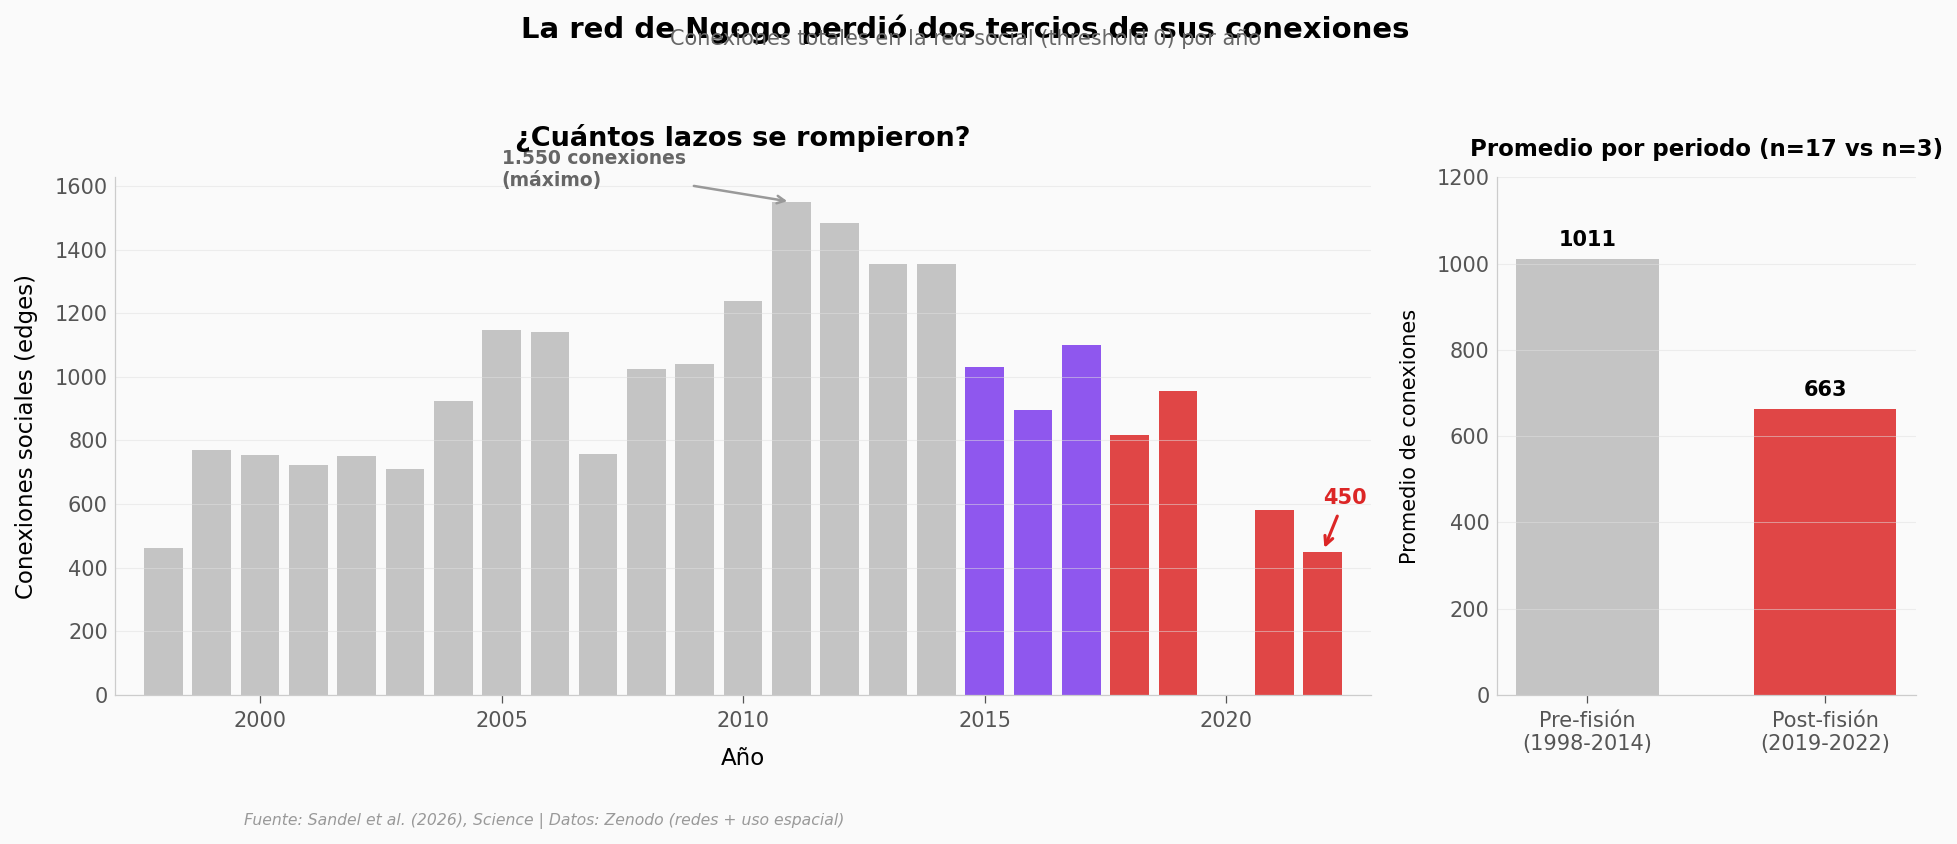

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5), gridspec_kw={'width_ratios': [3, 1]})

# Panel izquierdo: Conexiones totales (edges) por año
colors = [COLOR_PRE if y < ANIO_QUIEBRE else 
          COLOR_QUIEBRE if y < ANIO_FISION else 
          COLOR_ALERTA for y in red['year']]

ax1.bar(red['year'], red['n_edges'], color=colors, alpha=0.85, width=0.8)

# Anotaciones
ax1.annotate('1.550 conexiones\n(máximo)', xy=(2011, 1550),
             xytext=(2005, 1600), fontsize=9, fontweight='bold', color='#666666',
             arrowprops=dict(arrowstyle='->', color='#999999', lw=1.2))

ax1.annotate('450', xy=(2022, 450), xytext=(2022, 600),
             fontsize=10, fontweight='bold', color=COLOR_ALERTA,
             arrowprops=dict(arrowstyle='->', color=COLOR_ALERTA, lw=1.5))

ax1.set_xlabel('Año', fontsize=11)
ax1.set_ylabel('Conexiones sociales (edges)', fontsize=11)
ax1.set_title('¿Cuántos lazos se rompieron?',
              fontsize=13, fontweight='bold', pad=15)
ax1.set_xlim(1997, 2023)

# Panel derecho: Comparación pre vs post
periodos = ['Pre-fisión\n(1998-2014)', 'Post-fisión\n(2019-2022)']
medias = [red[red['year'] <= 2014]['n_edges'].mean(),
          red[red['year'] >= 2019]['n_edges'].mean()]

bars = ax2.bar(periodos, medias, color=[COLOR_PRE, COLOR_ALERTA], alpha=0.85, width=0.6)
for bar, val in zip(bars, medias):
    ax2.text(bar.get_x() + bar.get_width()/2, val + 30,
             f'{val:.0f}', ha='center', fontweight='bold', fontsize=10)

ax2.set_ylabel('Promedio de conexiones', fontsize=10)
ax2.set_title('Promedio por periodo (n=17 vs n=3)', fontsize=11, fontweight='bold', pad=10)
ax2.set_ylim(0, 1200)

fig.suptitle('La red de Ngogo perdió dos tercios de sus conexiones',
             fontsize=14, fontweight='bold', y=1.04)
fig.text(0.5, 1.00, 'Conexiones totales en la red social (threshold 0) por año',
         fontsize=10, color='#666666', ha='center')

plt.tight_layout()
fig.text(0.13, -0.04, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/conexiones_perdidas.png', dpi=200, bbox_inches='tight')
plt.show()

## ¿Qué tan anómalo es lo que pasó en 2022?

Veamos dónde cae el nivel de conectividad de 2022 comparado con toda la historia de Ngogo.

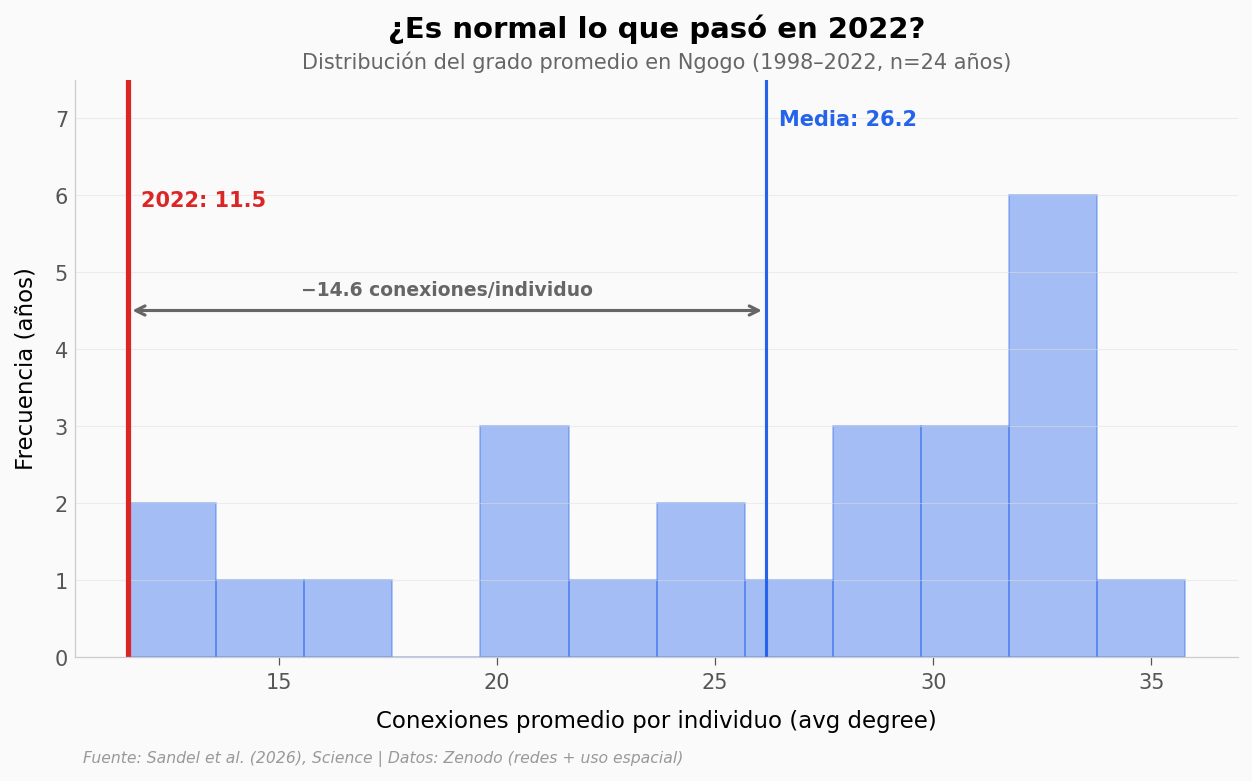

In [5]:
fig, ax = plt.subplots(figsize=(10, 5))

data = red['avg_degree'].values
media = np.mean(data)
valor_2022 = red[red['year'] == 2022]['avg_degree'].values[0]

n, bins, patches = ax.hist(data, bins=12, color=COLOR_CENTRAL, alpha=0.4,
                           edgecolor=COLOR_CENTRAL, linewidth=0.8)
y_max = n.max() * 1.25
ax.set_ylim(0, y_max)

# Media histórica
ax.axvline(x=media, color=COLOR_CENTRAL, linewidth=1.5, linestyle='-')
ax.text(media + 0.3, y_max * 0.92, f'Media: {media:.1f}',
        fontsize=10, color=COLOR_CENTRAL, fontweight='bold')

# Valor 2022
ax.axvline(x=valor_2022, color=COLOR_ALERTA, linewidth=2.5)
ax.text(valor_2022 + 0.3, y_max * 0.78, f'2022: {valor_2022:.1f}',
        fontsize=10, color=COLOR_ALERTA, fontweight='bold')

# Flecha bidireccional
y_arrow = y_max * 0.6
ax.annotate('', xy=(valor_2022, y_arrow), xytext=(media, y_arrow),
            arrowprops=dict(arrowstyle='<->', color='#666666', lw=1.5))
diff = media - valor_2022
ax.text((media + valor_2022) / 2, y_arrow + 0.2,
        f'−{diff:.1f} conexiones/individuo',
        fontsize=9, color='#666666', ha='center', fontweight='bold')

ax.set_xlabel('Conexiones promedio por individuo (avg degree)', fontsize=11)
ax.set_ylabel('Frecuencia (años)', fontsize=11)
ax.set_title('¿Es normal lo que pasó en 2022?',
             fontsize=14, fontweight='bold', pad=20)
ax.text(0.5, 1.02, 'Distribución del grado promedio en Ngogo (1998–2022, n=24 años)',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/histograma_anomalia.png', dpi=200, bbox_inches='tight')
plt.show()

### Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|------------|-------------|---------|
| La red social se fractura en 2015 | ✅ | avg_degree cae de 31,88 (2014) a 21,26 (2015): −33% en un año (Spearman ρ = −1,000 post-2015, p < 0,001, n = 7 años — sin datos de 2020) |
| Para 2022, la conectividad cae un 67,7% | ✅ | avg_degree de 35,77 (1999, pico) a 11,54 (2022). Verificado en los datos |
| La comunidad pasa de 124 a 78 individuos | ✅ | grupo_composicion.csv: 2019=124, 2022=78 (−37,1%) |
| Las conexiones totales caen de 1.355 a 450 | ✅ | red_social.csv: 2014=1.355, 2022=450 (−66,8%) |
| 24 ataques, ≥7 machos y 17 crías muertas | ⚠️ | Del abstract del paper. No tenemos datos granulares de ataques (Dryad bloqueado). Los datos de red y población son consistentes con conflicto letal sostenido |
| Es el primer caso documentado de "guerra civil" en primates | ⚠️ | El paper lo enmarca como primer caso con datos completos. Gombe (1970s) es un precedente, pero con observaciones limitadas y provisión de comida |

> **Limitaciones:**
> - Los datos de red cubren 1998-2022 (sin 2020, sin 2023-2024). La agresión letal continúa hasta 2024 según el paper.
> - La membresía de clústeres (124 individuos en el pico) no incluye a todos los ~200 miembros de la comunidad — solo a los que el equipo pudo rastrear con suficiente detalle.
> - No pudimos acceder a los datos de patrullas (Dryad bloqueado) ni al paper completo (paywall).
> - Los datos de ataques vienen del abstract y fragmentos del paper, no de datos tabulados verificables.
> - Las redes usan un umbral binario (threshold 0); con umbrales más altos, la fragmentación puede ser más o menos pronunciada.

## Ahora tú

Tres preguntas para explorar:

1. **¿Y si el quiebre hubiera sido en otro año?** Cambia `ANIO_QUIEBRE` a 2010 o 2017. ¿Se ve igual de dramático el cambio? (Pista: el 2015 no es arbitrario — el paper detectó un cambio estructural con análisis estadístico formal).

2. **¿Quién perdió más conexiones — los Western o los Central?** La celda de abajo carga la membresía por clúster. ¿Qué grupo tenía más miembros y cuál perdió más entre 2019 y 2022?

3. **¿Hay un "punto de no retorno"?** Usando los datos de `red_social.csv`, ¿en qué año la caída de avg_degree se acelera? Prueba dividir los años en segmentos de 5 y computar la pendiente de cada uno.

In [6]:
# --- EXPERIMENTA AQUÍ ---
# ¿Quién perdió más miembros entre 2019 y 2022?

comp_2019 = grupos[grupos['year'] == 2019].iloc[0]
comp_2022 = grupos[grupos['year'] == 2022].iloc[0]

print("Cambio 2019 → 2022:")
print(f"  Western:      {comp_2019['west']:>3.0f} → {comp_2022['west']:>3.0f}  ({comp_2022['west'] - comp_2019['west']:+.0f})")
print(f"  Central-East: {comp_2019['central_east']:>3.0f} → {comp_2022['central_east']:>3.0f}  ({comp_2022['central_east'] - comp_2019['central_east']:+.0f})")
print(f"  Total:        {comp_2019['total']:>3.0f} → {comp_2022['total']:>3.0f}  ({comp_2022['total'] - comp_2019['total']:+.0f})")

# Pérdida proporcional
w_loss = (comp_2019['west'] - comp_2022['west']) / comp_2019['west'] * 100
ce_loss = (comp_2019['central_east'] - comp_2022['central_east']) / comp_2019['central_east'] * 100
print(f"\nPérdida proporcional:")
print(f"  Western:      {w_loss:.1f}%")
print(f"  Central-East: {ce_loss:.1f}%")
print(f"\n{'Western' if w_loss > ce_loss else 'Central-East'} perdió proporcionalmente más miembros.")

Cambio 2019 → 2022:
  Western:       47 →  27  (-20)
  Central-East:  77 →  51  (-26)
  Total:        124 →  78  (-46)

Pérdida proporcional:
  Western:      42.6%
  Central-East: 33.8%

Western perdió proporcionalmente más miembros.


---

### Créditos

- **Paper:** Sandel, A.A., He, Y., Ren, J., Kei, Y.L., Lee, K.C., Clark, I.R., ... & Mitani, J.C. (2026). Lethal conflict after group fission in wild chimpanzees. *Science*, 388(6794). DOI: [10.1126/science.adz4944](https://doi.org/10.1126/science.adz4944)
- **Datos de redes sociales:** [Zenodo 18626723](https://doi.org/10.5281/zenodo.18626723) — Dataset and Code for Network Analysis
- **Datos de uso espacial:** [Zenodo 18603419](https://doi.org/10.5281/zenodo.18603419) — Space Use Analysis
- **Datos de redes aprendidas:** [Zenodo 19210783](https://doi.org/10.5281/zenodo.19210783) — Learned Network Analysis
- **Licencia datos:** CC-BY según Zenodo
- **Repo:** [github.com/Ciencia-a-Mordiscos/lab](https://github.com/Ciencia-a-Mordiscos/lab)